# Importing the dataset and necessary libraries

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler # To normalize the values before the clustering
from sklearn.metrics import silhouette_score # To optimize number of clusters
from sklearn_extra.cluster import KMedoids # To perform k-medoids clustering
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from scipy import stats
import warnings 
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
data = pd.read_csv("social_media_engagement_data_reduced.csv")

In [3]:
data.sample(10)

,level_0,Platform,Post ID,Post Type,Post Content,Post Timestamp,Date,Weekday Type,Time,Time Periods,...,Engagement Rate,Audience Age,Age Group,Audience Gender,Audience Location,Audience Continent,Audience Interests,Campaign ID,Sentiment,Influencer ID
3733,7557,Twitter,a46ce51f-165e-499a-9b14-21f7497bba39,Image,Pass figure house size contain box.,1/11/2023 6:05,1/11/2023 (Wednesday),Weekday,6:05:31,Morning,...,36.20,63,Senior Adults,Female,Lebanon,Asia,affect,NaN,Mixed,NaN
3129,6325,Instagram,67ffc202-cf6a-4918-86ae-d3009c171c49,Image,Get similar series appear around imagine.,11/30/2021 19:34,11/30/2021 (Tuesday),Weekday,19:34:53,Evening,...,14.05,46,Senior Adults,Other,Poland,Europe,just,NaN,Mixed,NaN
5671,11479,LinkedIn,0e457848-e850-466b-9850-eb0f00f354e1,Image,Information free simply.,2/15/2024 20:59,2/15/2024 (Thursday),Weekday,20:59:32,Evening,...,25.05,18,Adolescent Adults,Male,Falkland Islands (Malvinas),SouthAmerica,every,9e5d6ac4-bd5f-48c7-a93f-1fec8b25f3be,Mixed,NaN
2360,4782,Twitter,f1143751-79c0-47bf-b5f8-464dc5cd9e46,Video,Despite goal information quickly.,5/24/2021 8:03,5/24/2021 (Monday),Weekday,8:03:26,Morning,...,39.40,34,Mature Adults,Male,Haiti,NorthAmerica,value,NaN,Neutral,NaN
5899,11957,Twitter,faf7a0b0-a4fa-47a7-a89a-20e1148aabb6,Image,Wait fight continue almost unit close fine.,3/31/2021 23:15,3/31/2021 (Wednesday),Weekday,23:15:18,Night,...,29.63,39,Mature Adults,Male,Saint Barthelemy,NorthAmerica,treat,NaN,Positive,NaN
4038,8179,LinkedIn,d26ddb4b-a95f-4c98-a4e4-fbc594ad74d6,Image,Receive center wonder management.,5/1/2021 15:59,5/1/2021 (Saturday),Weekend,15:59:30,Afternoon,...,50.06,55,Senior Adults,Male,Ukraine,Europe,school,07c28820-80b0-4b0e-bc32-dc6b457f30f2,Mixed,0ab7b0f1-69ce-4ada-b464-174a23f072d5
877,1738,LinkedIn,c5208ac8-0203-4d65-9df9-2c850c0b2480,Link,Character during news usually near.,4/12/2021 22:49,4/12/2021 (Monday),Weekday,22:49:05,Night,...,30.09,62,Senior Adults,Male,Wallis and Futuna,Oceania,join,NaN,Mixed,NaN
6840,13883,Facebook,c6c70de4-6a31-456a-8eb8-89e3f7c6fddc,Video,Part agreement clear.,3/19/2023 19:03,3/19/2023 (Sunday),Weekend,19:03:28,Evening,...,20.92,49,Senior Adults,Female,Ireland,Europe,particularly,NaN,Positive,NaN
6531,13240,Facebook,10f379dc-4762-46d2-8fae-fa53d776907a,Link,Seem appear my PM strategy television individual.,2/17/2023 17:26,2/17/2023 (Friday),Weekday,17:26:03,Afternoon,...,19.58,46,Senior Adults,Female,China,Asia,weight,NaN,Positive,NaN
87,179,Twitter,159186c9-7f7b-41bf-9cec-de1377467484,Image,Almost feel others without type space challenge.,2/13/2023 19:09,2/13/2023 (Monday),Weekday,19:09:12,Evening,...,55.09,41,Mature Adults,Male,Morocco,Africa,receive,f7fdcae4-8f3f-45f5-bbef-43eb41abfb6d,Positive,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6996 entries, 0 to 6995
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   level_0             6996 non-null   int64  
 1   Platform            6996 non-null   object 
 2   Post ID             6996 non-null   object 
 3   Post Type           6996 non-null   object 
 4   Post Content        6996 non-null   object 
 5   Post Timestamp      6996 non-null   object 
 6   Date                6996 non-null   object 
 7   Weekday Type        6996 non-null   object 
 8   Time                6996 non-null   object 
 9   Time Periods        6996 non-null   object 
 10  Likes               6996 non-null   int64  
 11  Comments            6996 non-null   int64  
 12  Shares              6996 non-null   int64  
 13  Impressions         6996 non-null   int64  
 14  Reach               6996 non-null   int64  
 15   Engagement Rate    6996 non-null   float64
 16  Audien

In [5]:
data.describe()

,level_0,Likes,Comments,Shares,Impressions,Reach,Engagement Rate,Audience Age
count,6996.000000,6996.000000,6996.000000,6996.000000,6996.000000,6996.000000,6996.000000,6996.000000
mean,7071.396941,1316.745998,1070.553745,920.919240,5709.163665,3282.866352,47.373263,41.696398
std,4099.053265,522.695182,454.832262,433.004768,2308.431166,1295.697504,38.223464,13.888071
min,1.000000,100.000000,101.000000,100.000000,1016.000000,609.000000,1.040000,18.000000
25%,3557.750000,950.000000,739.000000,636.000000,3907.750000,2254.000000,22.270000,30.000000
50%,7062.500000,1323.000000,1054.000000,941.000000,5429.500000,3137.000000,34.925000,42.000000
75%,10598.250000,1693.000000,1385.000000,1302.000000,7663.250000,4260.250000,59.910000,54.000000
max,14190.000000,2599.000000,2100.000000,1800.000000,10000.000000,6600.000000,294.650000,65.000000


## Cleaning

In [6]:
# Removing unnecessary columns from the dataset
unimportant_columns = ['Influencer ID', 'Campaign ID', 'Time', 'Date']
unimportant_columns_exist = all(col in data.columns for col in unimportant_columns)

if unimportant_columns_exist:
    data = data.drop(unimportant_columns, axis=1)
    print("Unimportant columns removed successfully.") 
else:
    print("all of the unimportant columns do not exist in the DataFrame")
data

Unimportant columns removed successfully.


,level_0,Platform,Post ID,Post Type,Post Content,Post Timestamp,Weekday Type,Time Periods,Likes,Comments,...,Impressions,Reach,Engagement Rate,Audience Age,Age Group,Audience Gender,Audience Location,Audience Continent,Audience Interests,Sentiment
0,1,Twitter,d38fb961-2499-4488-a127-b6624e63f4dd,Image,Late event guess price.,7/12/2022 8:53,Weekday,Morning,2273,1609,...,3917,4704,42.48,34,Mature Adults,Female,Moldova,Europe,husband,Neutral
1,5,Twitter,f630bfa8-f4e4-489c-916a-79ac27919342,Image,Speech player daughter design.,12/8/2023 12:43,Weekday,Afternoon,2110,1773,...,3738,2844,87.56,41,Mature Adults,Male,Christmas Island,Oceania,light,Neutral
2,8,Twitter,bf5f5a98-da85-4379-83d3-60b86ba6ed51,Image,Such pay everyone financial.,5/26/2023 8:10,Weekday,Morning,2156,1543,...,4692,5830,26.42,40,Mature Adults,Other,Brunei Darussalam,Asia,far,Mixed
3,10,Facebook,fd839329-993f-4902-864e-96d0827fd7c2,Video,Center article improve kid all though trial.,8/21/2021 22:18,Weekend,Night,1127,1144,...,3482,2038,56.68,21,Adolescent Adults,Other,Sri Lanka,Asia,adult,Negative
4,11,Facebook,49792d7b-f082-43fb-889c-e718b8887933,Video,Buy state approach decide.,11/29/2023 21:35,Weekday,Evening,1692,1144,...,2560,3097,53.57,64,Senior Adults,Other,Uganda,Africa,account,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6991,14182,Twitter,836641db-a2e3-4b18-99c5-83efef22c585,Video,Rock respond trial student matter final.,7/16/2021 8:50,Weekday,Morning,2533,1825,...,1792,2717,119.70,25,Adolescent Adults,Male,Kenya,Africa,both,Negative
6992,14184,Facebook,7287e013-35f8-4cb2-a5cf-62695b9053d1,Image,Thousand factor half full.,10/10/2022 21:55,Weekday,Evening,1573,975,...,6781,4405,38.55,29,Adolescent Adults,Other,New Caledonia,Oceania,fall,Mixed
6993,14185,Instagram,b9b56a9f-5551-4a52-9d6c-24ea100d9ff0,Video,Future street player to special begin behavior.,9/22/2021 23:24,Weekday,Night,1714,1703,...,4032,2249,90.09,47,Senior Adults,Other,Hong Kong,Asia,home,Negative
6994,14189,Twitter,10c539ac-30a8-49bf-a2e7-63b7503d0d7c,Video,Chance kitchen car daughter approach through.,6/30/2023 4:01,Weekday,Night,1998,1741,...,5153,5355,16.62,55,Senior Adults,Other,Sweden,Europe,least,Negative


In [7]:
# Removing null values & duplicates
data = data.dropna()
data = data.drop_duplicates()

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6996 entries, 0 to 6995
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   level_0             6996 non-null   int64  
 1   Platform            6996 non-null   object 
 2   Post ID             6996 non-null   object 
 3   Post Type           6996 non-null   object 
 4   Post Content        6996 non-null   object 
 5   Post Timestamp      6996 non-null   object 
 6   Weekday Type        6996 non-null   object 
 7   Time Periods        6996 non-null   object 
 8   Likes               6996 non-null   int64  
 9   Comments            6996 non-null   int64  
 10  Shares              6996 non-null   int64  
 11  Impressions         6996 non-null   int64  
 12  Reach               6996 non-null   int64  
 13   Engagement Rate    6996 non-null   float64
 14  Audience Age        6996 non-null   int64  
 15  Age Group           6996 non-null   object 
 16  Audien

In [9]:
# Making sure that columns have the correct names & datatypes
data['Post Timestamp'] = pd.to_datetime(data['Post Timestamp'])
data.rename(columns={' Engagement Rate ': 'Engagement Rate'}, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6996 entries, 0 to 6995
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   level_0             6996 non-null   int64         
 1   Platform            6996 non-null   object        
 2   Post ID             6996 non-null   object        
 3   Post Type           6996 non-null   object        
 4   Post Content        6996 non-null   object        
 5   Post Timestamp      6996 non-null   datetime64[ns]
 6   Weekday Type        6996 non-null   object        
 7   Time Periods        6996 non-null   object        
 8   Likes               6996 non-null   int64         
 9   Comments            6996 non-null   int64         
 10  Shares              6996 non-null   int64         
 11  Impressions         6996 non-null   int64         
 12  Reach               6996 non-null   int64         
 13  Engagement Rate     6996 non-null   float64     

## Visualization

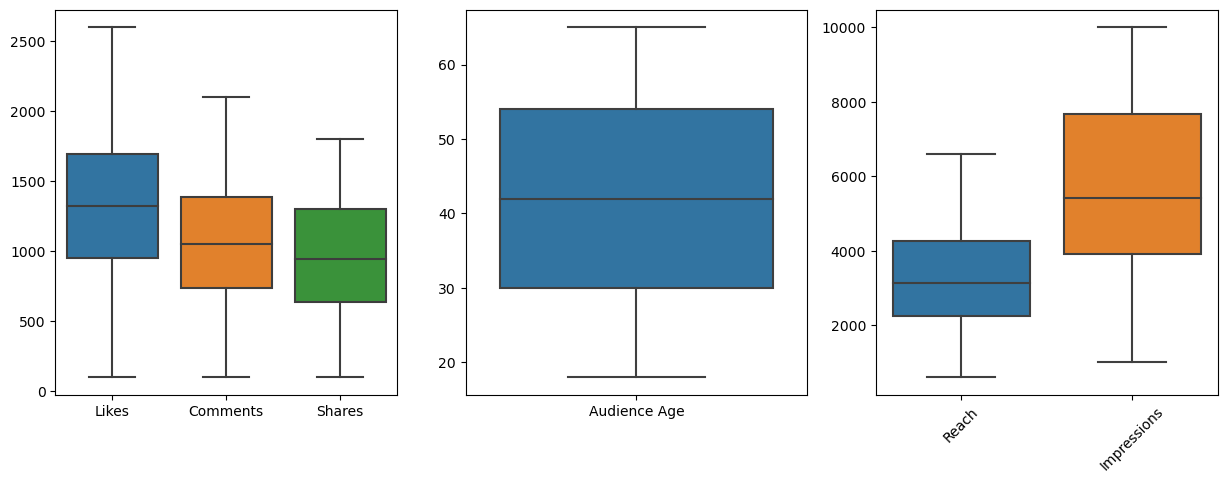

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

columns_of_interest1 = ['Likes', 'Comments', 'Shares']
sns.boxplot(data=data[columns_of_interest1], ax = axs[0])
#plt.xticks(rotation=)

columns_of_interest2 = ['Audience Age']
sns.boxplot(data=data[columns_of_interest2], ax = axs[1])
plt.xticks(rotation=45)

columns_of_interest3 = ['Reach', 'Impressions']
sns.boxplot(data=data[columns_of_interest3], ax = axs[2])

plt.show()

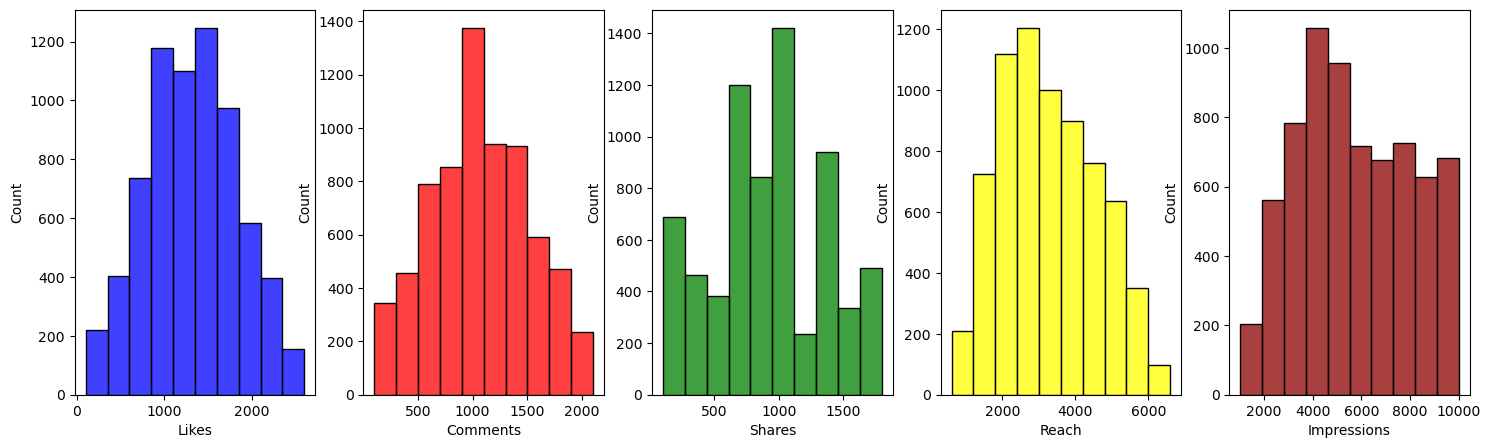

In [11]:
fig, axs = plt.subplots(1, 5, figsize=(18, 5))

# Visualize the distribution 
sns.histplot(data=data, x='Likes', bins=10, ax = axs[0], color = 'Blue')

sns.histplot(data=data, x='Comments', bins=10, ax = axs[1], color = 'Red')

sns.histplot(data=data, x='Shares', bins=10, ax = axs[2], color = 'Green')

sns.histplot(data=data, x='Reach', bins=10, ax = axs[3], color = 'Yellow')

sns.histplot(data=data, x='Impressions', bins=10, ax = axs[4], color = 'darkRed')

plt.show()

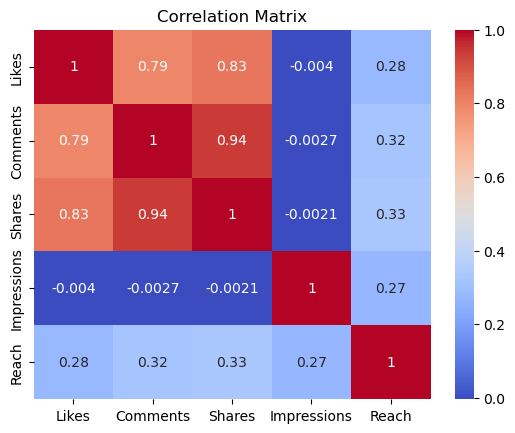

In [12]:
correlation_matrix = data[['Likes', 'Comments', 'Shares', 'Impressions', 'Reach']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

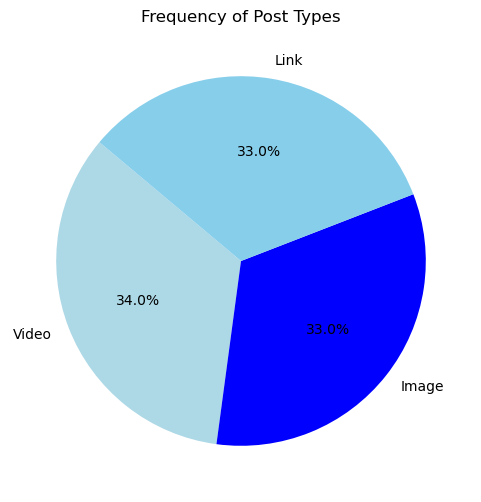

In [13]:
frequency = data['Post Type'].value_counts()

# Define custom colors
colors = ['lightblue', 'blue', 'skyblue']

plt.figure(figsize=(6, 6))
plt.pie(frequency.values, labels=frequency.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Frequency of Post Types')
plt.show()

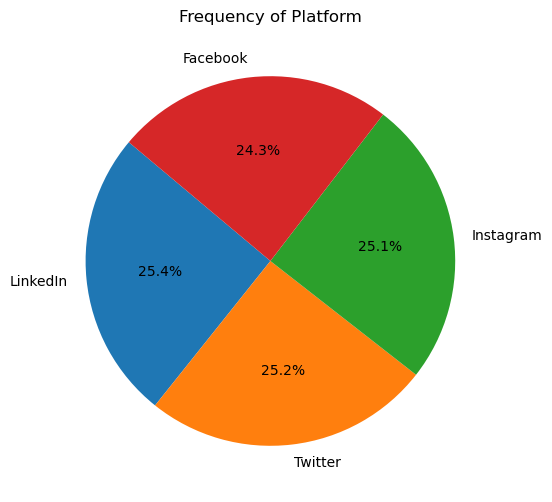

In [14]:
frequency = data['Platform'].value_counts()

# Define custom colors
colors = ['yellow', 'glod', "red", 'blue']

plt.figure(figsize=(6, 6))
plt.pie(frequency.values, labels=frequency.index, autopct='%1.1f%%', startangle=140)
plt.title('Frequency of Platform')
plt.show()

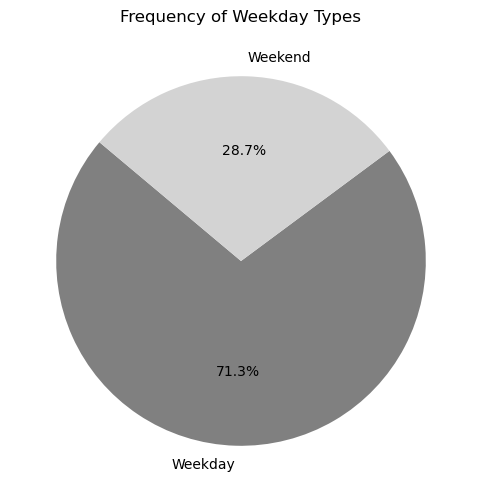

In [15]:
frequency = data['Weekday Type'].value_counts()

# Define custom colors
colors = ['gray', 'lightgray']

plt.figure(figsize=(6, 6))
plt.pie(frequency.values, labels=frequency.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Frequency of Weekday Types')
plt.show()

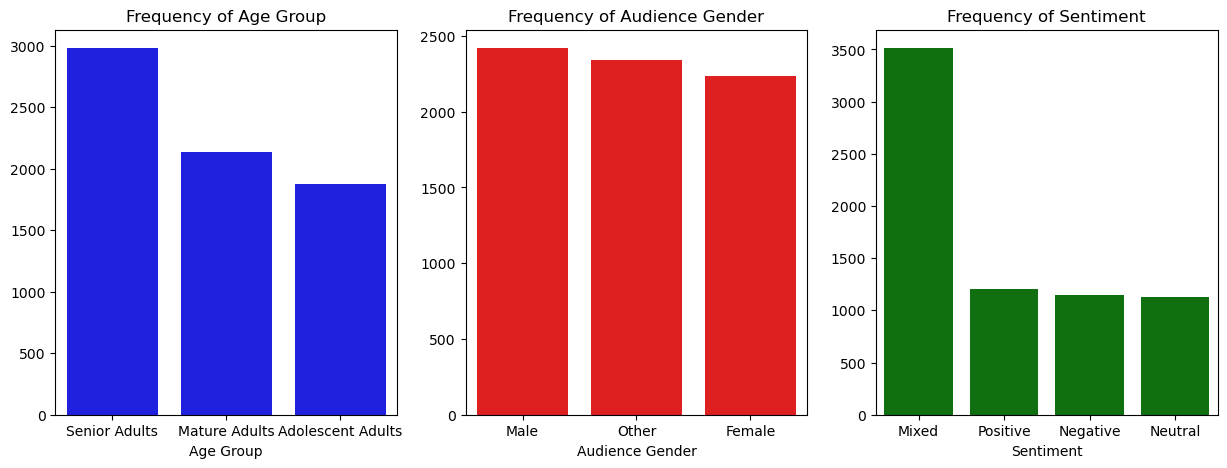

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
frequency = data['Age Group'].value_counts()
sns.barplot(x = frequency.index, y = frequency.values, color='blue', ax = axs[0])
axs[0].set_title('Frequency of Age Group')

frequency = data['Audience Gender'].value_counts()
sns.barplot(x = frequency.index, y = frequency.values, color='red', ax = axs[1])
axs[1].set_title('Frequency of Audience Gender')

frequency = data['Sentiment'].value_counts()
sns.barplot(x = frequency.index, y = frequency.values, color='green', ax = axs[2])
axs[2].set_title('Frequency of Sentiment')


plt.show()

In [17]:
slope, intercept, r_value, p_value, std_err = stats.linregress(data['Likes'], data['Reach'])
r_squared = r_value ** 2
print("R-squared for likes vs reach:", r_squared)


slope, intercept, r_value, p_value, std_err = stats.linregress(data['Comments'], data['Reach'])
r_squared = r_value ** 2
print("R-squared for comments vs reach:", r_squared)


slope, intercept, r_value, p_value, std_err = stats.linregress(data['Shares'], data['Reach'])
r_squared = r_value ** 2
print("R-squared for shares vs reach:", r_squared)


slope, intercept, r_value, p_value, std_err = stats.linregress(data['Likes'], data['Comments'])
r_squared = r_value ** 2
print("R-squared for likes vs comments:", r_squared)

R-squared for likes vs reach: 0.07840302840537733
R-squared for comments vs reach: 0.1014991505446059
R-squared for shares vs reach: 0.1106076293794018
R-squared for likes vs comments: 0.6300509663789525


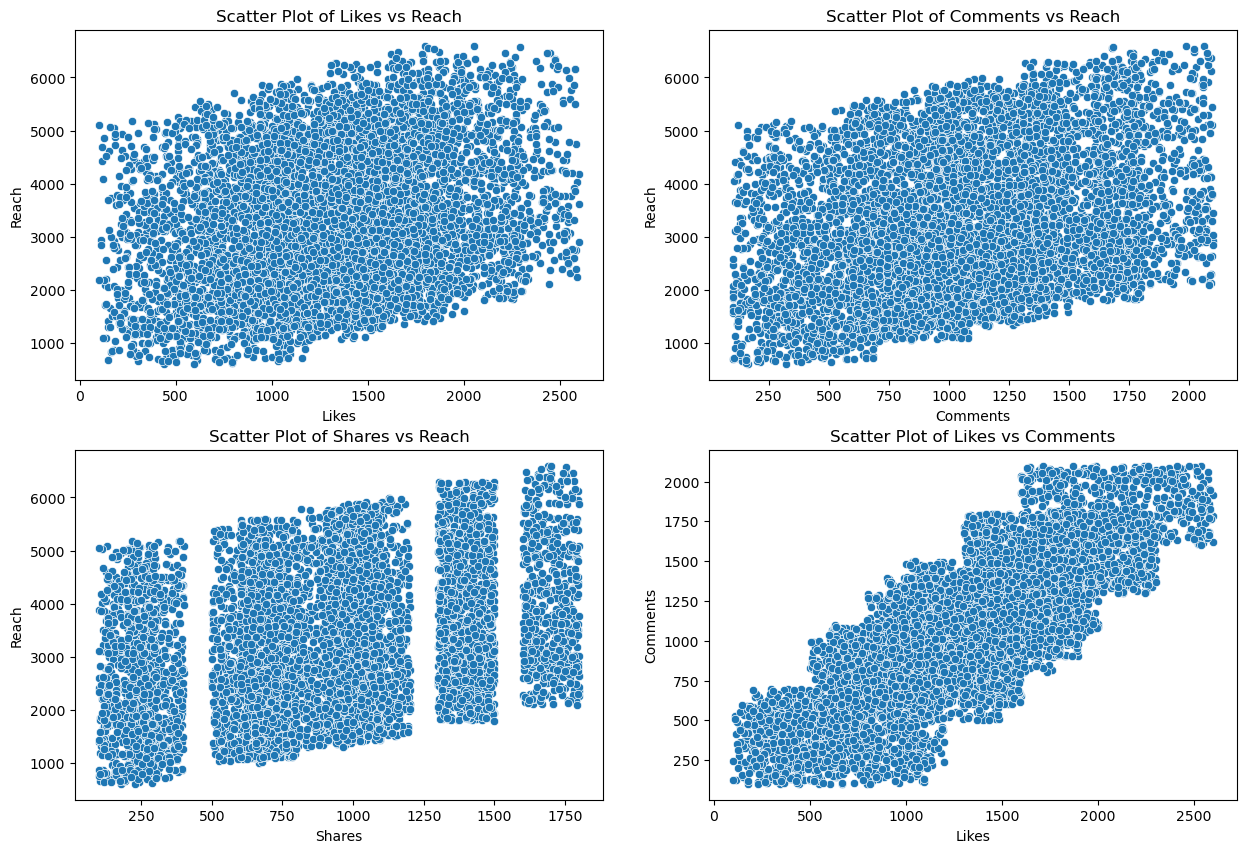

In [18]:
fig, axes = plt.subplots(2, 2, figsize = (15, 10))

sns.scatterplot(x = data['Likes'], y = data['Reach'], ax = axes[0, 0])
axes[0, 0].set_title('Scatter Plot of Likes vs Reach')

sns.scatterplot(x = data['Comments'], y = data['Reach'], ax = axes[0, 1])
axes[0, 1].set_title('Scatter Plot of Comments vs Reach')

sns.scatterplot(x = data['Shares'], y = data['Reach'], ax = axes[1, 0])
axes[1, 0].set_title('Scatter Plot of Shares vs Reach')

sns.scatterplot(x = data['Likes'], y = data['Comments'], ax = axes[1, 1])
axes[1, 1].set_title('Scatter Plot of Likes vs Comments')

plt.show()

## Modeling: K-Medoids

## Goal of the analysis
Perform K-medoids clustering on the data to gain insights on the following:
Which combinations of platform & post type usually perform better?

Based on 2 metrics: 

1- Engagment(Likes, comments,  and shares)

2- Reach

In [19]:
# Choosing only the necessary columns for clustering
columns_for_clustering = data[['Likes', 'Comments', 'Shares', 'Reach']]

# Normalization
scaler = MinMaxScaler()
columns_for_clustering_normalized = scaler.fit_transform(columns_for_clustering)

normalized_df = pd.DataFrame(columns_for_clustering_normalized, columns=['Likes', 'Comments', 'Shares', 'Reach'])

normalized_df.describe()

,Likes,Comments,Shares,Reach
count,6996.000000,6996.000000,6996.000000,6996.000000
mean,0.486893,0.485019,0.482894,0.446314
std,0.209162,0.227530,0.254709,0.216274
min,0.000000,0.000000,0.000000,0.000000
25%,0.340136,0.319160,0.315294,0.274579
50%,0.489396,0.476738,0.494706,0.421966
75%,0.637455,0.642321,0.707059,0.609456
max,1.000000,1.000000,1.000000,1.000000


In [20]:
normalized_df['Engagment Total'] = normalized_df['Likes'] + normalized_df['Comments'] + normalized_df['Shares']
normalized_df.drop(['Likes', 'Comments', 'Shares'], axis=1, inplace=True)

In [21]:
normalized_df.head()

,Reach,Engagment Total
0,0.683525,2.426278
1,0.373060,2.387211
2,0.871474,2.307619
3,0.238524,1.505666
4,0.415290,1.712345


> Performing k medoids clustering, and comparing silhouette scores to determine the best number of clusters

Here's a simple explanation of the silhouette score:

1. **Cohesion (How Close the Points Are to Each Other)**: For each data point in a cluster, the silhouette score measures how close it is to the other points in the same cluster. A high cohesion means that the points within the same cluster are close to each other.

2. **Separation (How Far Apart the Clusters Are)**: The silhouette score also considers how far apart the clusters are from each other. It measures the distance between a data point and the points in the nearest neighboring cluster. A high separation means that the clusters are well-separated from each other.

3. **Silhouette Score Calculation**: The silhouette score is calculated for each data point using the formula:

   Silhouette Score = (b - a)/max(a, b)
   
   where:
   - \(a\) is the average distance from the data point to other points in the same cluster (cohesion).
   - \(b\) is the average distance from the data point to points in the nearest neighboring cluster (separation).
   - The silhouette score ranges from -1 to 1:
     - A score close to +1 indicates that the data point is well-clustered and far from other clusters.
     - A score close to 0 indicates that the data point is close to the decision boundary between clusters.
     - A score close to -1 indicates that the data point may have been assigned to the wrong cluster.

4. **Interpretation**: To interpret the silhouette score:
   - A higher average silhouette score across all data points indicates better clustering.
   - Negative silhouette scores suggest that the data may have been clustered incorrectly.

In summary, the silhouette score provides a way to evaluate the quality of clustering results by considering both how close the points are within clusters and how well-separated the clusters are from each other. Higher silhouette scores indicate better clustering.

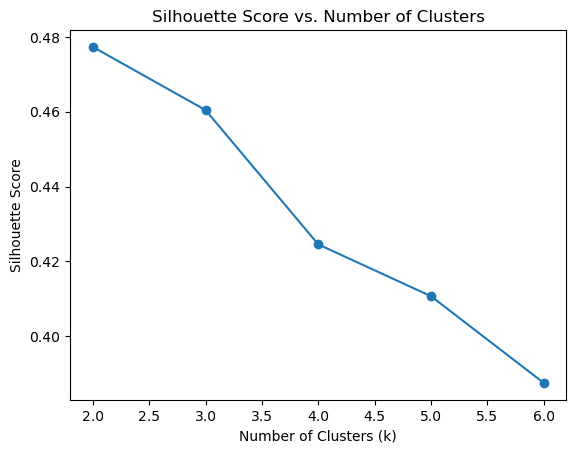

Optimal number of clusters: 2


In [22]:
k_values = range(2, 7)

# List to store silhouette scores
silhouette_scores = []

# Iterate over each value of k
for k in k_values:
    # Fit K-Medoids clustering model
    # We set the random seed number to a specific value to ensure that the algorithm starts with the same centers each time
    kmedoids = KMedoids(n_clusters=k, random_state=42).fit(normalized_df)
    # Compute silhouette score
    silhouette_scores.append(silhouette_score(normalized_df, kmedoids.labels_))

# Plot silhouette scores for different values of k
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()

# Choose the value of k that maximizes silhouette score
optimal_k = k_values[np.argmax(silhouette_scores)]
print("Optimal number of clusters:", optimal_k)

In [49]:
kmedoids = KMedoids(n_clusters=optimal_k, random_state=42).fit(normalized_df)

In [50]:
normalized_df['Cluster'] = kmedoids.labels_
normalized_df.head()

,Reach,Engagment Total,Cluster
0,0.683525,2.426278,0
1,0.373060,2.387211,0
2,0.871474,2.307619,0
3,0.238524,1.505666,1
4,0.415290,1.712345,0


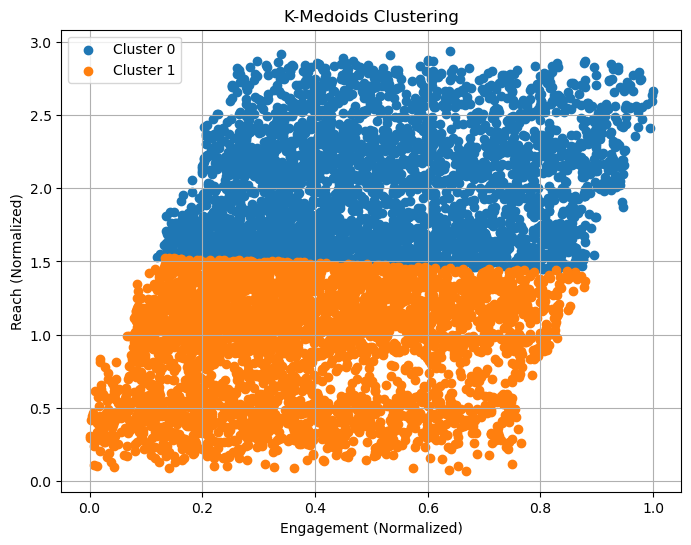

In [51]:
plt.figure(figsize=(8, 6))

cluster_labels = kmedoids.labels_

# Iterate over each unique cluster label
for cluster_label in np.unique(cluster_labels):
    # Filter data points belonging to the current cluster
    cluster_points = normalized_df.values[cluster_labels == cluster_label]
    
    # Plot the data points with a different color for each cluster
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_label}')

plt.title('K-Medoids Clustering')
plt.xlabel('Engagement (Normalized)')
plt.ylabel('Reach (Normalized)')
plt.legend()
plt.grid(True)
plt.show()

In [52]:
data['Cluster'] = kmedoids.labels_

In [53]:
data.head()

,level_0,Platform,Post ID,Post Type,Post Content,Post Timestamp,Weekday Type,Time Periods,Likes,Comments,...,Audience Age,Age Group,Audience Gender,Audience Location,Audience Continent,Audience Interests,Sentiment,Cluster,predicted_reach,reach_classification
0,1,Twitter,d38fb961-2499-4488-a127-b6624e63f4dd,Image,Late event guess price.,2022-07-12 08:53:00,Weekday,Morning,2273,1609,...,34,Mature Adults,Female,Moldova,Europe,husband,Neutral,0,4500.0,very_high
1,5,Twitter,f630bfa8-f4e4-489c-916a-79ac27919342,Image,Speech player daughter design.,2023-12-08 12:43:00,Weekday,Afternoon,2110,1773,...,41,Mature Adults,Male,Christmas Island,Oceania,light,Neutral,0,4500.0,very_high
2,8,Twitter,bf5f5a98-da85-4379-83d3-60b86ba6ed51,Image,Such pay everyone financial.,2023-05-26 08:10:00,Weekday,Morning,2156,1543,...,40,Mature Adults,Other,Brunei Darussalam,Asia,far,Mixed,0,4500.0,very_high
3,10,Facebook,fd839329-993f-4902-864e-96d0827fd7c2,Video,Center article improve kid all though trial.,2021-08-21 22:18:00,Weekend,Night,1127,1144,...,21,Adolescent Adults,Other,Sri Lanka,Asia,adult,Negative,1,4500.0,very_high
4,11,Facebook,49792d7b-f082-43fb-889c-e718b8887933,Video,Buy state approach decide.,2023-11-29 21:35:00,Weekday,Evening,1692,1144,...,64,Senior Adults,Other,Uganda,Africa,account,Negative,0,4500.0,very_high


# Clustering Results

First, we group the data by platform and see how many instances of each platform are in each cluster. The platforms with the most posts in the better performing cluster are considered superior.

In [54]:
platform_results = data.groupby(['Platform', 'Cluster']).size().unstack(fill_value=0)

In [55]:
platform_results

Cluster,0,1
Platform,,
Facebook,419,1283
Instagram,1151,606
LinkedIn,199,1577
Twitter,1585,176


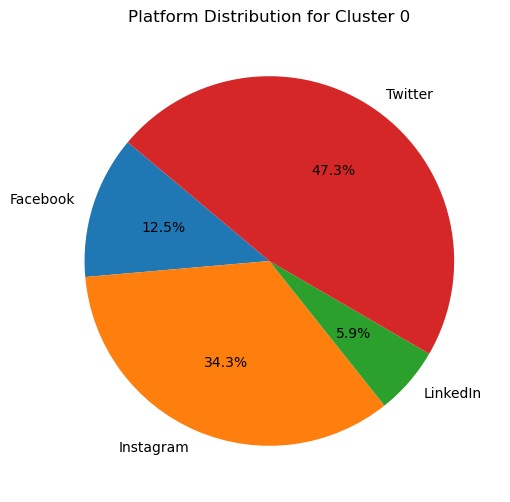

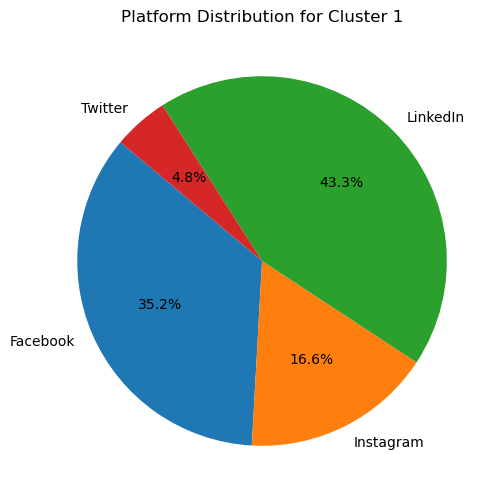

In [56]:
cluster_results = platform_results.T

for cluster in cluster_results.index:
    platform_distribution = cluster_results.loc[cluster]
    
    plt.figure(figsize=(6, 6)) 
    plt.pie(platform_distribution, labels=platform_distribution.index, autopct='%1.1f%%', startangle=140)
    
    plt.title(f'Platform Distribution for Cluster {cluster}')
    
    
    plt.show()

## Results: Twitter & Instagram usually perform better

Next, we do the same thing for post types

In [57]:
postType_results = data.groupby(['Post Type', 'Cluster']).size().unstack(fill_value=0)
postType_results

Cluster,0,1
Post Type,,
Image,1133,1176
Link,417,1892
Video,1804,574


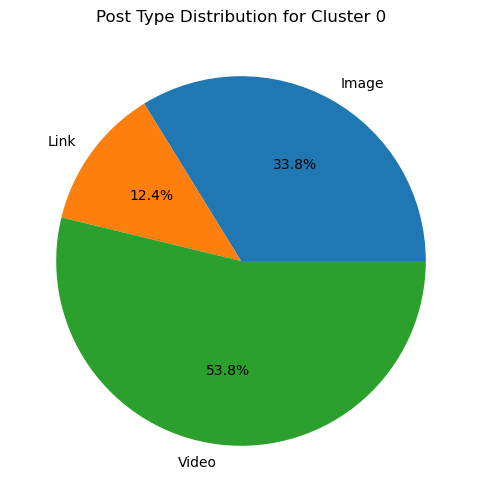

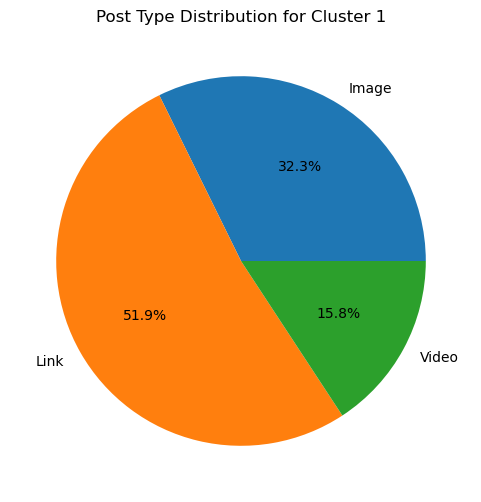

In [58]:
cluster_results = postType_results.T

# Plot a pie chart for each cluster
for cluster in cluster_results.index:
    # Get platform distribution for the current cluster
    postType_distribution = cluster_results.loc[cluster]
    
    # Create a pie chart
    plt.figure(figsize=(6, 6))  # Optional: Set the figure size
    plt.pie(postType_distribution, labels=postType_distribution.index, autopct='%1.1f%%')
    
    # Add a title with the cluster name
    plt.title(f'Post Type Distribution for Cluster {cluster}')
    
    
    # Show the pie chart
    plt.show()

## Results: Videos usually perform better

## Modeling: Fuzzy Clustering

In [33]:
# Find the maximum value in the 'reach' column
max_reach = data['Reach'].max()

# Find the minimum value in the 'reach' column
min_reach = data['Reach'].min()

print("Maximum Reach:", max_reach)
print("Minimum Reach:", min_reach)

Maximum Reach: 6600
Minimum Reach: 609


In [34]:
# Find the maximum value in the 'likes' column
max_likes = data['Likes'].max()

# Find the minimum value in the 'reach' column
min_likes = data['Likes'].min()

print("Maximum Likes:", max_likes)
print("Minimum Likes:", min_likes)

Maximum Likes: 2599
Minimum Likes: 100


In [35]:
# Find the maximum value in the 'Comments' column
max_Comments = data['Comments'].max()

# Find the minimum value in the 'reach' column
min_Comments = data['Comments'].min()

print("Maximum Comments:", max_Comments)
print("Minimum Comments:", min_Comments)

Maximum Comments: 2100
Minimum Comments: 101


In [36]:
# Find the maximum value in the 'Shares' column
max_Shares = data['Shares'].max()

# Find the minimum value in the 'Shares' column
min_Shares = data['Shares'].min()

print("Maximum Shares:", max_Shares)
print("Minimum Shares:", min_Shares)

Maximum Shares: 1800
Minimum Shares: 100


In [37]:
# Convert Numerical Attributes to Linguistic Variables
# Define linguistic variables and membership functions for likes, shares, comments, and reach

# Define linguistic variables for likes
likes = ctrl.Antecedent(np.arange(0, 1001, 1), 'likes')
likes['low'] = fuzz.trimf(likes.universe, [0, 0, 500])
likes['medium'] = fuzz.trimf(likes.universe, [250, 500, 750])
likes['high'] = fuzz.trimf(likes.universe, [500, 1000, 1000])

# Define linguistic variables for shares
shares = ctrl.Antecedent(np.arange(0, 201, 1), 'shares')
shares['low'] = fuzz.trimf(shares.universe, [0, 0, 100])
shares['medium'] = fuzz.trimf(shares.universe, [50, 100, 150])
shares['high'] = fuzz.trimf(shares.universe, [100, 200, 200])

# Define linguistic variables for comments
comments = ctrl.Antecedent(np.arange(0, 501, 1), 'comments')
comments['low'] = fuzz.trimf(comments.universe, [0, 0, 250])
comments['medium'] = fuzz.trimf(comments.universe, [125, 250, 375])
comments['high'] = fuzz.trimf(comments.universe, [250, 500, 500])

# Define linguistic variables for reach
reach = ctrl.Consequent(np.arange(500, 5001, 1), 'reach')
reach['very_low'] = fuzz.trimf(reach.universe, [500, 500, 1500])
reach['low'] = fuzz.trimf(reach.universe, [1000, 1500, 2500])
reach['medium'] = fuzz.trimf(reach.universe, [2000, 2500, 3500])
reach['high'] = fuzz.trimf(reach.universe, [3000, 3500, 4500])
reach['very_high'] = fuzz.trimf(reach.universe, [4000, 4500, 5000])

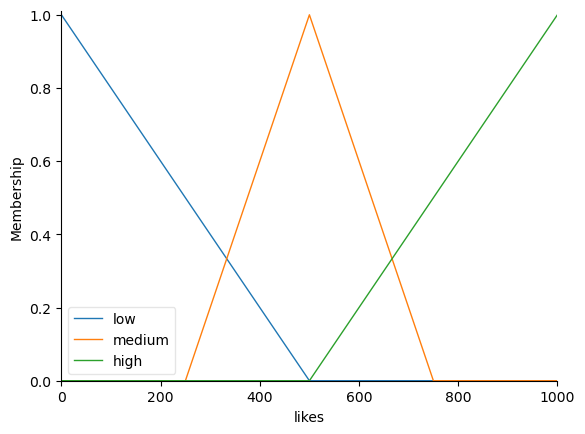

In [60]:
likes.view()

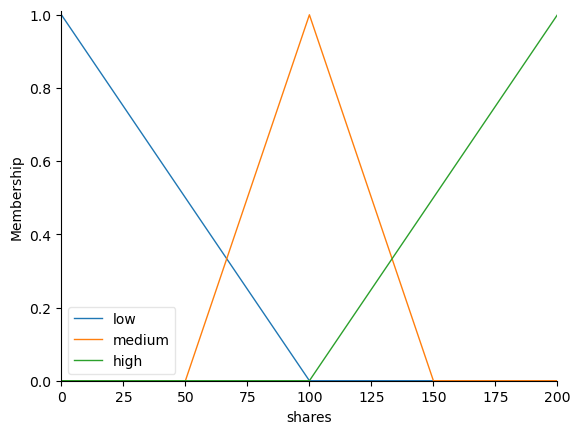

In [61]:
shares.view()

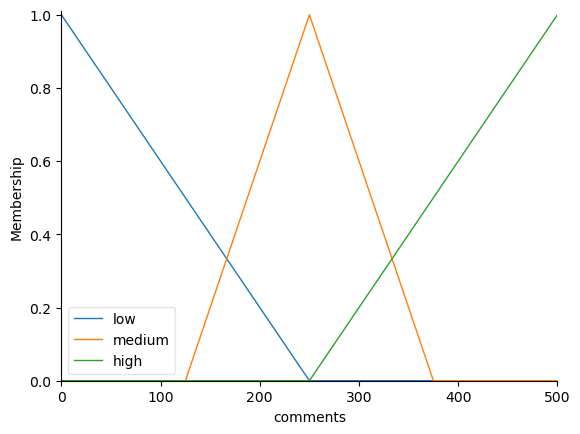

In [62]:
comments.view()

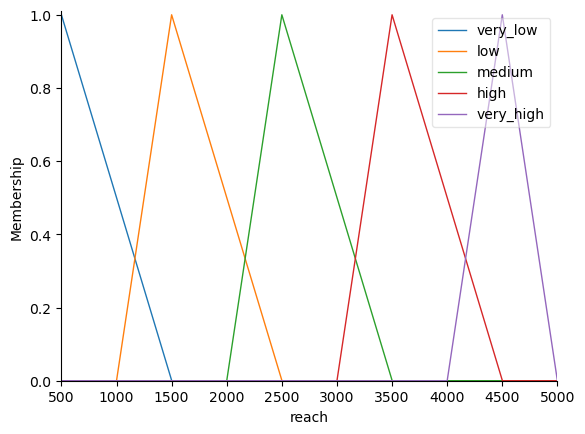

In [63]:
reach.view()

In [42]:
# Inference Rules
# Define fuzzy rules to infer membership of data points in clusters
# Rule 1 when low likes
rule1 = ctrl.Rule(likes['low'] & shares['low'] & comments['low'], reach['very_low'])
# Rule 2
rule2 = ctrl.Rule(likes['low'] & shares['low'] & comments['medium'], reach['low'])
# Rule 3
rule3 = ctrl.Rule(likes['low'] & shares['low'] & comments['high'], reach['medium'])
# Rule 4
rule4 = ctrl.Rule(likes['low'] & shares['medium'] & comments['low'], reach['low'])
# Rule 5
rule5 = ctrl.Rule(likes['low'] & shares['medium'] & comments['medium'], reach['medium'])
# Rule 6
rule6 = ctrl.Rule(likes['low'] & shares['medium'] & comments['high'], reach['high'])
# Rule 7
rule7 = ctrl.Rule(likes['low'] & shares['high'] & comments['low'], reach['medium'])
# Rule 8
rule8 = ctrl.Rule(likes['low'] & shares['high'] & comments['medium'], reach['high'])
# Rule 9
rule9 = ctrl.Rule(likes['low'] & shares['high'] & comments['high'], reach['very_high'])
# Rule 10
rule10 = ctrl.Rule(likes['medium'] & shares['low'] & comments['low'], reach['low'])
# Rule 11
rule11 = ctrl.Rule(likes['medium'] & shares['low'] & comments['medium'], reach['medium'])
# Rule 12
rule12 = ctrl.Rule(likes['medium'] & shares['low'] & comments['high'], reach['high'])
# Rule 13
rule13 = ctrl.Rule(likes['medium'] & shares['medium'] & comments['low'], reach['medium'])
# Rule 14
rule14 = ctrl.Rule(likes['medium'] & shares['medium'] & comments['medium'], reach['high'])
# Rule 15
rule15 = ctrl.Rule(likes['medium'] & shares['medium'] & comments['high'], reach['very_high'])
# Rule 16
rule16 = ctrl.Rule(likes['medium'] & shares['high'] & comments['low'], reach['high'])
# Rule 17
rule17 = ctrl.Rule(likes['medium'] & shares['high'] & comments['medium'], reach['very_high'])
# Rule 18
rule18 = ctrl.Rule(likes['medium'] & shares['high'] & comments['high'], reach['very_high'])
# Rule 19
rule19 = ctrl.Rule(likes['high'] & shares['low'] & comments['low'], reach['medium'])
# Rule 20
rule20 = ctrl.Rule(likes['high'] & shares['low'] & comments['medium'], reach['high'])
# Rule 21
rule21 = ctrl.Rule(likes['high'] & shares['low'] & comments['high'], reach['very_high'])
# Rule 22
rule22 = ctrl.Rule(likes['high'] & shares['medium'] & comments['low'], reach['high'])
# Rule 23
rule23 = ctrl.Rule(likes['high'] & shares['medium'] & comments['medium'], reach['very_high'])
# Rule 24
rule24 = ctrl.Rule(likes['high'] & shares['medium'] & comments['high'], reach['very_high'])
# Rule 25
rule25 = ctrl.Rule(likes['high'] & shares['high'] & comments['low'], reach['very_high'])
# Rule 26
rule26 = ctrl.Rule(likes['high'] & shares['high'] & comments['medium'], reach['very_high'])
# Rule 27
rule27 = ctrl.Rule(likes['high'] & shares['high'] & comments['high'], reach['very_high'])

In [43]:
social_media_system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20, rule21, rule22, rule23, rule24, rule25, rule26, rule27])

In [44]:
# Create fuzzy simulator
social_media_simulator = ctrl.ControlSystemSimulation(social_media_system)

In [45]:
# Apply the fuzzy logic clustering model to predict reach
predicted_reach = []
reach_classification = []
for index, row in data.iterrows():
    # Input values for the fuzzy logic model
    likes_val = row['Likes']
    shares_val = row['Shares']
    comments_val = row['Comments']
    
    # Reset the control system simulation for each iteration
    social_media_simulator.reset()
    
    # Set input values
    social_media_simulator.input['likes'] = likes_val
    social_media_simulator.input['shares'] = shares_val
    social_media_simulator.input['comments'] = comments_val
    
    # Compute the result
    social_media_simulator.compute()
    
    # Get the predicted reach
    predicted_reach_val = social_media_simulator.output['reach']
    # Classify predicted reach
    reach_class = np.argmax([fuzz.interp_membership(reach.universe, reach['very_low'].mf, predicted_reach_val),
                             fuzz.interp_membership(reach.universe, reach['low'].mf, predicted_reach_val),
                             fuzz.interp_membership(reach.universe, reach['medium'].mf, predicted_reach_val),
                             fuzz.interp_membership(reach.universe, reach['high'].mf, predicted_reach_val),
                             fuzz.interp_membership(reach.universe, reach['very_high'].mf, predicted_reach_val)])
    predicted_reach.append(predicted_reach_val)
    reach_classification.append(['very_low', 'low', 'medium', 'high', 'very_high'][reach_class])

# Step 3: Add the predicted reach values as a new column to the sample DataFrame
data['predicted_reach'] = predicted_reach
data['reach_classification'] = reach_classification

In [46]:
data.sample(10)

,level_0,Platform,Post ID,Post Type,Post Content,Post Timestamp,Weekday Type,Time Periods,Likes,Comments,...,Audience Age,Age Group,Audience Gender,Audience Location,Audience Continent,Audience Interests,Sentiment,Cluster,predicted_reach,reach_classification
5960,12088,LinkedIn,edf5a660-2200-47c0-8670-1af91133005d,Video,Student single draw idea throughout environmen...,2023-07-07 10:29:00,Weekday,Morning,847,1052,...,46,Senior Adults,Other,British Indian Ocean Territory (Chagos Archipe...,Africa,behind,Neutral,0,4500.0,very_high
6810,13814,Instagram,ca932999-28bc-4213-8b53-ff103ccc6e92,Video,Find catch member give generation support force.,2021-08-08 17:30:00,Weekend,Afternoon,1348,1769,...,30,Adolescent Adults,Male,Luxembourg,Europe,term,Positive,1,4500.0,very_high
6043,12251,LinkedIn,6ae1bdcb-89dc-4f39-98b9-855854e12843,Image,Face scientist moment important case firm minute.,2023-05-09 02:01:00,Weekday,Night,739,957,...,61,Senior Adults,Female,Chad,Africa,such,Positive,0,4500.0,very_high
5802,11760,Instagram,02fd8fcf-ce0c-4da0-b714-29229be201c0,Video,Growth market pretty produce.,2021-08-07 18:35:00,Weekend,Evening,1995,1398,...,62,Senior Adults,Male,Cambodia,Asia,fly,Positive,1,4500.0,very_high
4366,8811,Instagram,7b3f3f96-85f1-41df-89d1-7fb4b17907ef,Link,Easy hospital say on next.,2023-03-23 03:03:00,Weekday,Night,668,947,...,41,Mature Adults,Female,Australia,Oceania,method,Mixed,0,4500.0,very_high
4907,9873,Twitter,dd737ac6-4864-423e-a889-a4cef64947ec,Link,Painting include better hour east cover.,2022-02-04 23:25:00,Weekday,Night,1769,1115,...,36,Mature Adults,Female,American Samoa,Oceania,truth,Mixed,1,4500.0,very_high
5880,11919,LinkedIn,8fb29700-d2ff-4557-b219-18ef30d537e7,Image,Attorney have evening hotel without student.,2022-05-19 16:10:00,Weekday,Afternoon,1279,752,...,65,Senior Adults,Other,Heard Island and McDonald Islands,Oceania,participant,Neutral,0,4500.0,very_high
2838,5711,Twitter,66b80714-d7e5-4dc5-9ab0-e42e7fbad6c2,Video,Own expert century other factor responsibility.,2022-10-28 07:19:00,Weekday,Morning,1818,1768,...,42,Mature Adults,Male,Qatar,Asia,involve,Mixed,1,4500.0,very_high
2164,4393,Facebook,e4ae0676-af1b-4926-ac57-756ccb9ac6db,Link,Reason step individual medical author hold ins...,2021-05-05 10:16:00,Weekday,Morning,497,692,...,18,Adolescent Adults,Male,Christmas Island,Oceania,audience,Mixed,0,4500.0,very_high
149,308,Twitter,c5d38605-f028-4386-9880-b42b755b4412,Image,Low agent popular within pass speak.,2021-08-12 22:07:00,Weekday,Night,2122,1699,...,61,Senior Adults,Female,Bolivia,SouthAmerica,certainly,Neutral,1,4500.0,very_high


In [47]:
#The Algorithm on one example 
social_media_simulator.input['likes'] = 500 #medium likes
social_media_simulator.input['shares'] = 190 #high shares
social_media_simulator.input['comments'] = 300 #medium comments
social_media_simulator.compute()
predicted_reach_val = social_media_simulator.output['reach']
print(f"The predicted reach is {predicted_reach_val}")

The predicted reach is 4499.999999999982


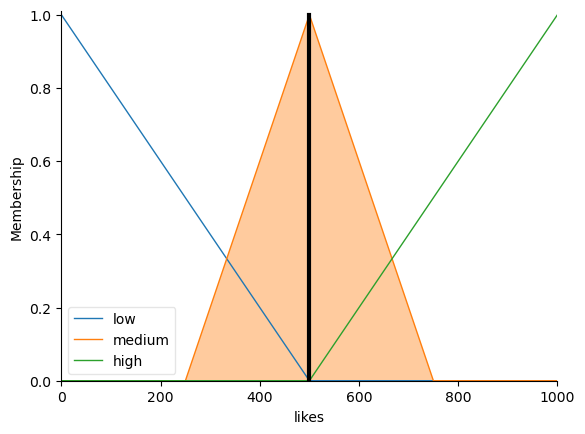

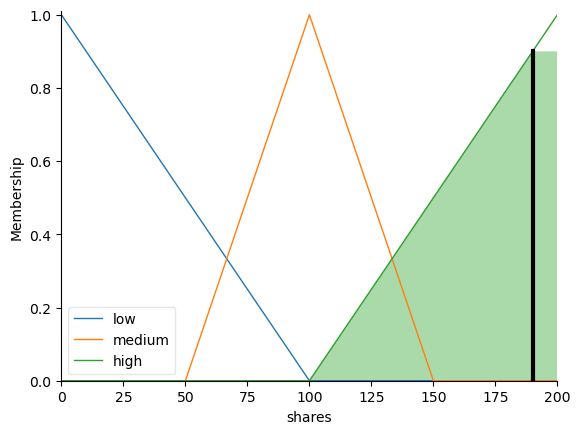

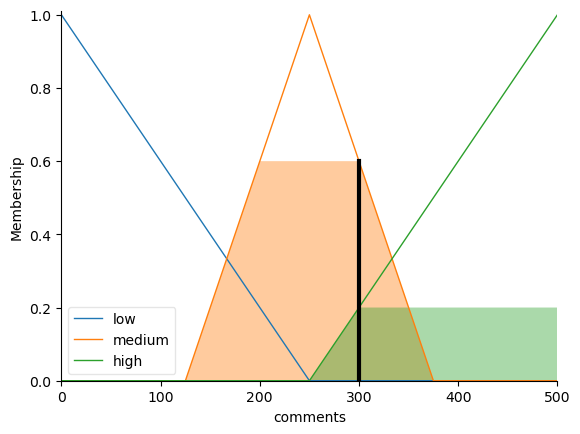

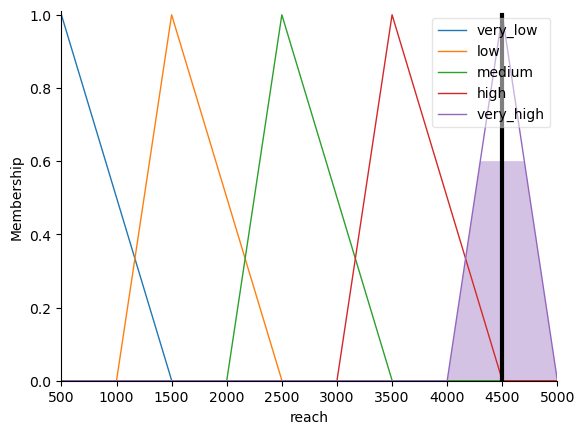

In [64]:
#visualization the fuzzy membership function
likes.view(social_media_simulator)
shares.view(social_media_simulator)
comments.view(social_media_simulator)
reach.view(social_media_simulator)